<a href="https://colab.research.google.com/github/thais30206/Projeto-Final.-Modulo-1/blob/work-in-progress/Proyecto_final_Modulo_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Fase 1: Análise Exploratória de Dados (EDA)**

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [2]:
# Cargar arquivo
df = pd.read_csv("credit_risk_dataset.csv")

# Ver primeras 5 filas
print(df.head())
print(df.shape)


   person_age  person_income person_home_ownership  person_emp_length  \
0          22          59000                  RENT              123.0   
1          21           9600                   OWN                5.0   
2          25           9600              MORTGAGE                1.0   
3          23          65500                  RENT                4.0   
4          24          54400                  RENT                8.0   

  loan_intent loan_grade  loan_amnt  loan_int_rate  loan_status  \
0    PERSONAL          D      35000          16.02            1   
1   EDUCATION          B       1000          11.14            0   
2     MEDICAL          C       5500          12.87            1   
3     MEDICAL          C      35000          15.23            1   
4     MEDICAL          C      35000          14.27            1   

   loan_percent_income cb_person_default_on_file  cb_person_cred_hist_length  
0                 0.59                         Y                           3  


In [3]:
colunas_con_nulos=df.isnull().sum()
print(colunas_con_nulos)

person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64


In [4]:
print(df.info())
print(df.describe())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB
None
         person_age  perso

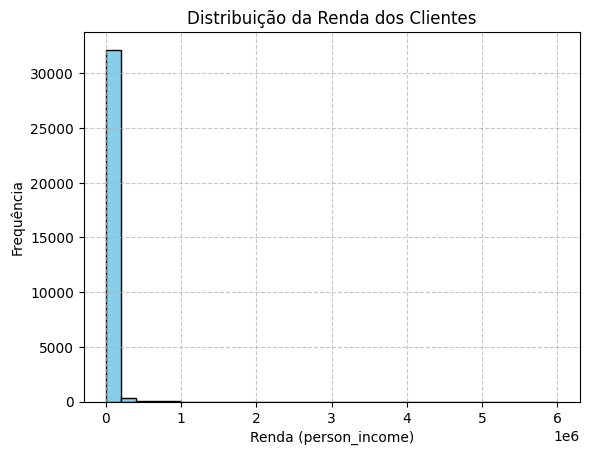

In [5]:

datos = df['person_income']
# Crear histograma
plt.hist(datos, bins=30, color='skyblue', edgecolor='black')

# Etiquetas
plt.title('Distribuição da Renda dos Clientes')
plt.xlabel('Renda (person_income)')
plt.ylabel('Frequência')
plt.grid(True, linestyle="--", alpha=0.7)

# Mostrar gráfico
plt.show()


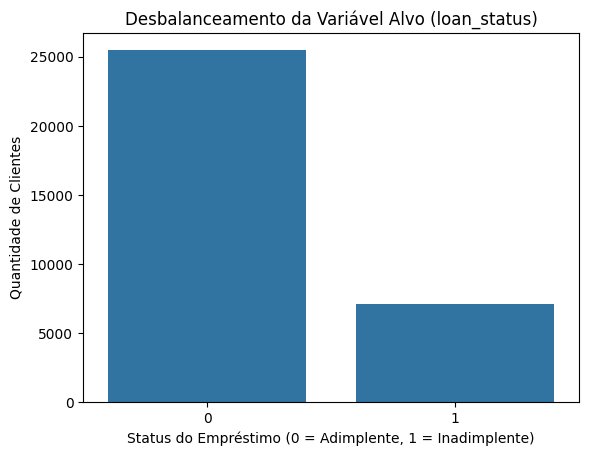

In [6]:
# Crear gráfico
sns.countplot(x='loan_status', data=df)
plt.title('Desbalanceamento da Variável Alvo (loan_status)')
plt.xlabel('Status do Empréstimo (0 = Adimplente, 1 = Inadimplente)')
plt.ylabel('Quantidade de Clientes')


plt.show()


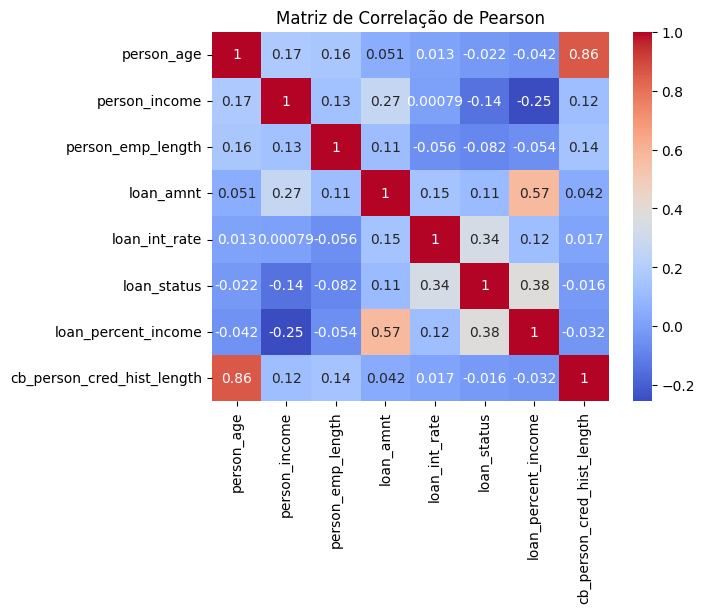

In [7]:
matriz_corr = df.select_dtypes(include=['number']).corr()
sns.heatmap(matriz_corr, annot=True, cmap='coolwarm')
plt.title('Matriz de Correlação de Pearson')
# Mostrar el gráfico
plt.show()

**Tomada de Decisão (EDA)**

A análise exploratória revelou que os dados apresentam assimetria na distribuição de renda (person_income) e valores ausentes nas variáveis person_emp_length e loan_int_rate, exigindo estratégias específicas de imputação e tratamento de outliers. Constatou-se um desequilíbrio significativo na variável alvo (loan_status), onde aproximadamente apenas 22% dos registros representam inadimplência, evidenciando a necessidade de balanceamento via reamostragem (como SMOTE) na fase de treino para evitar métricas ilusórias de acurácia. Por fim, a matriz de correlação indicou alta colinearidade (0,86) entre a idade (person_age) e o tempo de histórico de crédito (cb_person_cred_hist_length), insight fundamental que guiará a preparação e o comportamento dos modelos preditivos.



# **Fase 2: Tratamento e Limpeza (Data Prep)**

In [8]:
df.duplicated().sum()
print("Duplicados antes:", df.duplicated().sum())
df=df.drop_duplicates()


print("Duplicados depois:", df.duplicated().sum())
print("Novo tamanho dataset:", df.shape)

Duplicados antes: 165
Duplicados depois: 0
Novo tamanho dataset: (32416, 12)


In [9]:
df[['person_emp_length', 'loan_int_rate']].describe()

,person_emp_length,loan_int_rate
count,31529.00000,29321.000000
mean,4.79051,11.017265
std,4.14549,3.241680
min,0.00000,5.420000
25%,2.00000,7.900000
50%,4.00000,10.990000
75%,7.00000,13.470000
max,123.00000,23.220000


In [10]:
mediana_emp = df['person_emp_length'].median()
df['person_emp_length'] = df['person_emp_length'].fillna(mediana_emp)

mediana_rate = df['loan_int_rate'].median()
df['loan_int_rate'] = df['loan_int_rate'].fillna(mediana_rate)

print(df[['person_emp_length', 'loan_int_rate']].isnull().sum())

person_emp_length    0
loan_int_rate        0
dtype: int64


 **Tratamento de Valores Ausentes (Data Prep)**

Foram identificados valores nulos nas variáveis person_emp_length e loan_int_rate. A análise estatística descritiva revelou forte assimetria e a presença de outliers extremos nas distribuições (como tempos de emprego discrepantes no valor máximo). Por esse motivo, optou-se pela imputação dos dados ausentes utilizando a Mediana em ambas as colunas, garantindo que os valores atribuídos representem a tendência central sem a distorção causada pelos valores discrepantes.

In [11]:
# 1. Verificar o tamanho original antes do filtro
print("Tamanho original:", df.shape)

# 2. Filtrar mantendo apenas dados válidos
df = df[(df['person_age'] < 100) & (df['person_emp_length'] < 60)]

# 3. Verificar o novo tamanho após a remoção de outliers
print("Novo tamanho:", df.shape)

Tamanho original: (32416, 12)
Novo tamanho: (32409, 12)


**Tratamento de Outliers**

Foram identificados e removidos 7 registros com valores discrepantes e irrealistas na base de dados (person_age >= 100 e person_emp_length >= 60). Essa filtragem é fundamental para garantir a estabilidade do pipeline e otimizar o desempenho do algoritmo KNN, que é altamente sensível a distorções causadas por outliers no cálculo das distâncias euclidianas.

# **Fase 3: Feature Engineering**

In [12]:
df['comprometimento_renda'] = df['loan_amnt'] / df['person_income']*100.
print (df)

       person_age  person_income person_home_ownership  person_emp_length  \
1              21           9600                   OWN                5.0   
2              25           9600              MORTGAGE                1.0   
3              23          65500                  RENT                4.0   
4              24          54400                  RENT                8.0   
5              21           9900                   OWN                2.0   
...           ...            ...                   ...                ...   
32576          57          53000              MORTGAGE                1.0   
32577          54         120000              MORTGAGE                4.0   
32578          65          76000                  RENT                3.0   
32579          56         150000              MORTGAGE                5.0   
32580          66          42000                  RENT                2.0   

           loan_intent loan_grade  loan_amnt  loan_int_rate  loan_status  \

In [13]:
# Verificar se existem valores nulos ou infinitos na nova coluna
print("Nulos:", df['comprometimento_renda'].isnull().sum())
print("Infinitos:", df['comprometimento_renda'].isin([float('inf'), float('-inf')]).sum())
print(df['comprometimento_renda'].describe())

Nulos: 0
Infinitos: 0
count    32409.000000
mean        17.059651
std         10.705381
min          0.078947
25%          8.972231
50%         14.814815
75%         22.916667
max         83.000000
Name: comprometimento_renda, dtype: float64


Foi criada a nova variável numérica comprometimento_renda, calculada pela relação percentual entre o valor do empréstimo solicitado (loan_amnt) e a renda anual do cliente (person_income). Essa feature reflete a taxa de comprometimento financeiro do tomador de crédito, sendo um preditor de alto valor para os modelos de classificação. O cálculo foi executado com sucesso e verificado quanto à ausência de valores nulos ou infinitos.

# **Fase 4: Separação, Balanceamento e Escalonamento Seguro**

In [14]:
df.dtypes

,0
person_age,int64
person_income,int64
person_home_ownership,object
person_emp_length,float64
loan_intent,object
loan_grade,object
loan_amnt,int64
loan_int_rate,float64
loan_status,int64
loan_percent_income,float64


In [16]:
df_dummies = pd.get_dummies(df, columns=['person_home_ownership','loan_intent', 'loan_grade', 'cb_person_default_on_file'], drop_first=True)
df_dummies.shape

(32409, 24)

Encodagem de Variáveis Categóricas (Encoding)

As variáveis categóricas (person_home_ownership, loan_intent, loan_grade e cb_person_default_on_file) foram convertidas em formato numérico através da técnica de One-Hot Encoding utilizando pd.get_dummies(drop_first=True). O argumento drop_first=True foi aplicado para evitar a armadilha das variáveis fictícias (dummy variable trap) e mitigar problemas de multicolinearidade.

In [22]:
# 1. Separar as variáveis preditoras (X) da variável alvo (y)
X = df_dummies.drop(columns=['loan_status'])
y = df_dummies['loan_status']

# 2. Divisão estratificada em Treino (80%) e Teste (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# 3. Exibir dimensões
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

X_train: (25927, 23)
X_test: (6482, 23)


 Divisão dos Dados (Train/Test Split)

 O conjunto de dados foi dividido em variáveis preditoras ($X$) e variável alvo ($y$). Foi realizada a divisão em 80% para treino e 20% para teste utilizando o parâmetro stratify=y, garantindo a preservação exata da proporção das classes (adimplentes vs. inadimplentes) em ambas as bases.

In [25]:
X_train_res, y_train_res = SMOTE(random_state=42).fit_resample(X_train, y_train)

print ('Desbalance original', y_train.value_counts())

print( y_train_res.value_counts())

Desbalance original loan_status
0    20257
1     5670
Name: count, dtype: int64
loan_status
0    20257
1    20257
Name: count, dtype: int64


Balanceamento de Classes sem Data Leakage

Para tratar o desbalanceamento da classe alvo, aplicou-se a técnica de sobreamostragem SMOTE (Synthetic Minority Over-sampling Technique). Seguindo as boas práticas para evitar a fuga de dados (Data Leakage), o balanceamento foi executado estritamente sobre o conjunto de treino (X_train e y_train), preservando o conjunto de teste (X_test e y_test) intacto com a distribuição original do mercado.